In [3]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
from watermark.auto_watermark import AutoWatermark
from utils.diffusion_config import DiffusionConfig
from diffusers import TextToVideoSDPipeline, StableVideoDiffusionPipeline
from diffusers import DPMSolverMultistepScheduler, DDIMInverseScheduler, DDIMScheduler
from dotenv import load_dotenv
load_dotenv()

#model_path = os.getenv('T2V_MODEL_PATH')
model_path = "damo-vilab/text-to-video-ms-1.7b"
scheduler = DDIMScheduler.from_pretrained(model_path, subfolder="scheduler")
device = 'cuda' if torch.cuda.is_available() else 'cpu'

pipe = TextToVideoSDPipeline.from_pretrained(
    model_path, 
    scheduler=scheduler,
    torch_dtype=torch.float16 if device == 'cuda' else torch.float32
).to(device)
diffusion_config = DiffusionConfig(
    pipe = pipe,
    scheduler = scheduler,
    device = device,
    image_size = (512, 512),        
    num_inference_steps = 25,       
    guidance_scale = 7.5,           
    gen_seed = 42,                  
    init_latents_seed= 36,         
    num_frames = 16,                
    inversion_type = "ddim"         
)
print(pipe.device)
print(device)

/home/nisp/anaconda3/envs/markdiff/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-18 20:40:35.616994: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-18 20:40:35.651883: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-18 20:40:36.477472: I tensorflow/core

cuda:0
cuda


In [4]:
import matplotlib.pyplot as plt
def display_frame(frame, title="Generated Frame"):
    plt.figure(figsize=(8, 8))
    plt.imshow(frame)
    plt.axis('off')
    plt.title(title)
    plt.show()
    
import os
import numpy as np
import cv2
from PIL import Image

def save_list_as_mp4(frames, out_mp4="outputs/watermarked.mp4", fps=8):
    os.makedirs(os.path.dirname(out_mp4) or ".", exist_ok=True)

    # 统一转成 uint8 RGB 的 numpy: (H, W, 3)
    rgb_frames = []
    for f in frames:
        if isinstance(f, Image.Image):
            arr = np.array(f.convert("RGB"), dtype=np.uint8)
        elif isinstance(f, np.ndarray):
            arr = f
            # 可能是 float [0,1] / [-1,1] 或 uint8
            if arr.dtype != np.uint8:
                if arr.min() < 0:  # [-1,1] -> [0,1]
                    arr = (arr + 1) / 2
                arr = (np.clip(arr, 0, 1) * 255).astype(np.uint8)
            # CHW -> HWC
            if arr.ndim == 3 and arr.shape[0] in (1,3,4) and arr.shape[-1] not in (1,3,4):
                arr = np.transpose(arr, (1,2,0))
            # 灰度 -> RGB
            if arr.ndim == 2:
                arr = np.stack([arr]*3, axis=-1)
            # RGBA -> RGB
            if arr.shape[-1] == 4:
                arr = arr[..., :3]
        else:
            raise TypeError(f"Unsupported frame type: {type(f)}")

        rgb_frames.append(arr)

    h, w = rgb_frames[0].shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(out_mp4, fourcc, fps, (w, h))

    for fr in rgb_frames:
        writer.write(cv2.cvtColor(fr, cv2.COLOR_RGB2BGR))  # OpenCV 用 BGR
    writer.release()

    print(f"Saved to: {out_mp4} (frames={len(rgb_frames)}, fps={fps}, size={w}x{h})")

# 用法


### 1.1 VideoShield Watermark Generation & Detection

  0%|          | 0/25 [00:00<?, ?it/s]

100%|██████████| 25/25 [00:19<00:00,  1.31it/s]


<class 'list'>
Saved to: outputs/watermarked.mp4 (frames=16, fps=8, size=512x512)


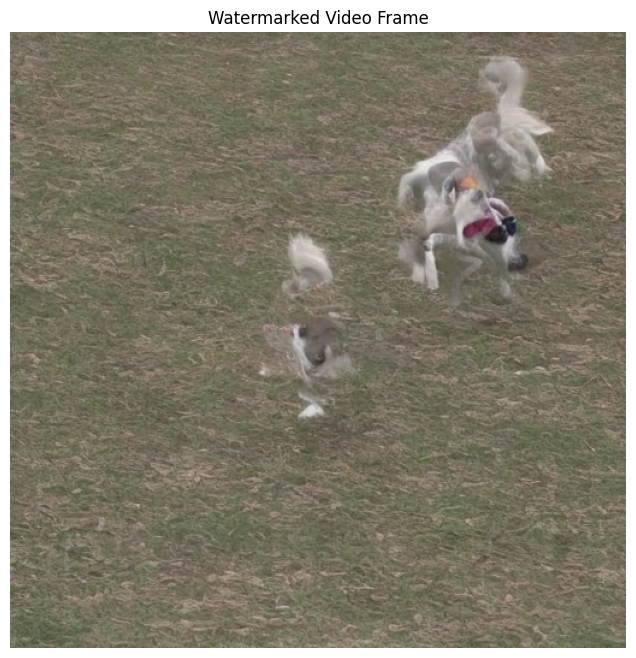

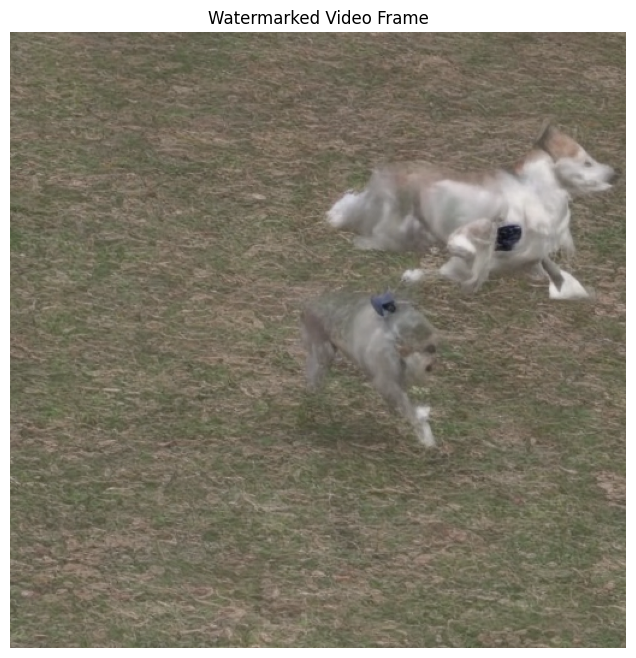

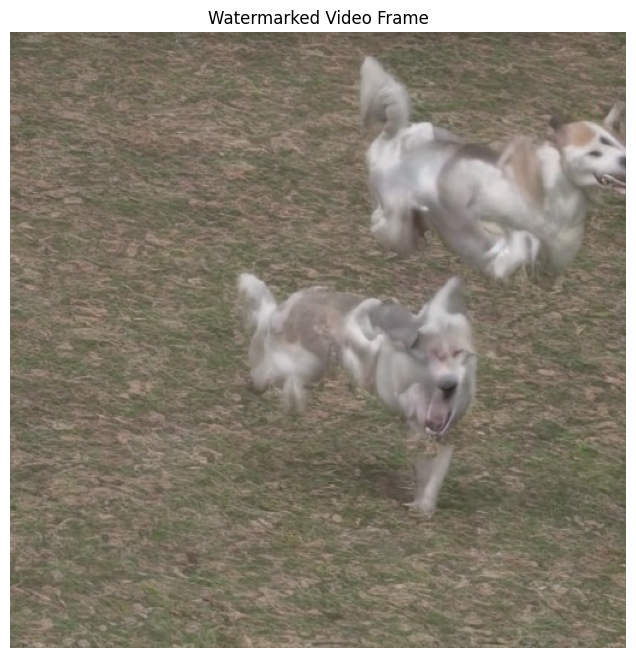

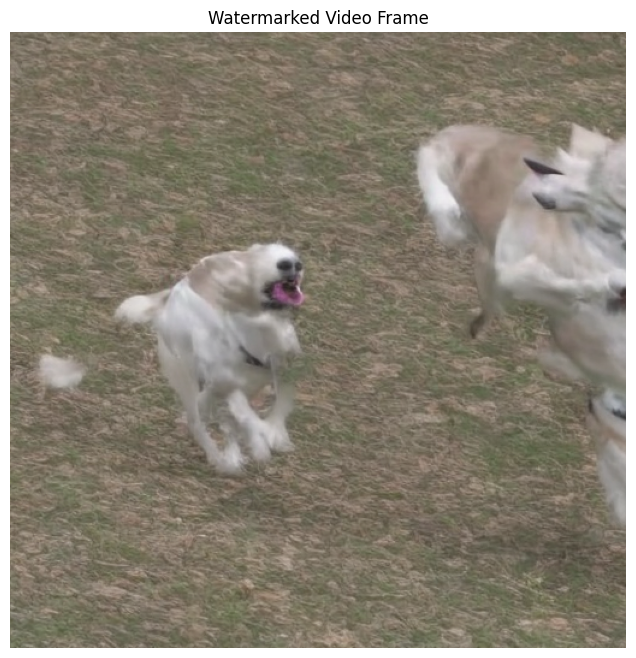

In [ ]:
mywatermark = AutoWatermark.load('VideoShield', algorithm_config=f'config/VideoShield.json', diffusion_config=diffusion_config)

unwatermarked_video = mywatermark.generate_unwatermarked_media(input_data="a dog running in the park")

watermarked_video = mywatermark.generate_watermarked_media(input_data="a dog running in the park", num_frames=16)
print(type(watermarked_video[0]))
save_list_as_mp4(watermarked_video, "outputs/watermarked.mp4", fps=8)
display_frame(watermarked_video[0], "Watermarked Video Frame")
display_frame(watermarked_video[5], "Watermarked Video Frame")
display_frame(watermarked_video[10], "Watermarked Video Frame")
display_frame(watermarked_video[15], "Watermarked Video Frame")


In [ ]:
detection_result = mywatermark.detect_watermark_in_media(watermarked_video, detector_type='bit_acc')
print("Watermarked test result:", detection_result)
    
detection_result = mywatermark.detect_watermark_in_media(unwatermarked_video, detector_type='bit_acc')
print("Unwatermarked test result:", detection_result)